# 내일 비가 올지 예측(Rain in Australia)
- 참고 : https://www.kaggle.com/prashant111/extensive-analysis-eda-fe-modelling
- 랜덤 포레스트(Random Forest)

# 관련 라이브러리 import

In [1]:
# 불필요한 경고 출력을 방지
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# 데이터 준비
- 아래 링크에서 weatherAUS.csv 파일을 다운로드 받기
#### https://www.kaggle.com/jsphyg/weather-dataset-rattle-package



## 데이터 읽기

In [183]:
df = pd.read_csv("datas_ml/weatherAUS.csv")
print(df.shape)

(145460, 23)


# EDA 수행

## 데이터 형상 파악하기

In [184]:
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No
145459,2017-06-25,Uluru,14.9,NaN,0.0,NaN,NaN,NaN,NaN,ESE,...,62.0,36.0,1020.2,1017.9,8.0,8.0,15.0,20.9,No,NaN


In [185]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [186]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


## 범주형 데이터 통계량 확인

In [187]:
cat_columns = df.select_dtypes(exclude=np.number).columns
cat_columns

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')

In [188]:
print(cat_columns)
df[cat_columns].describe()

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


## target(y) 데이터 확인

<Axes: xlabel='RainTomorrow', ylabel='count'>

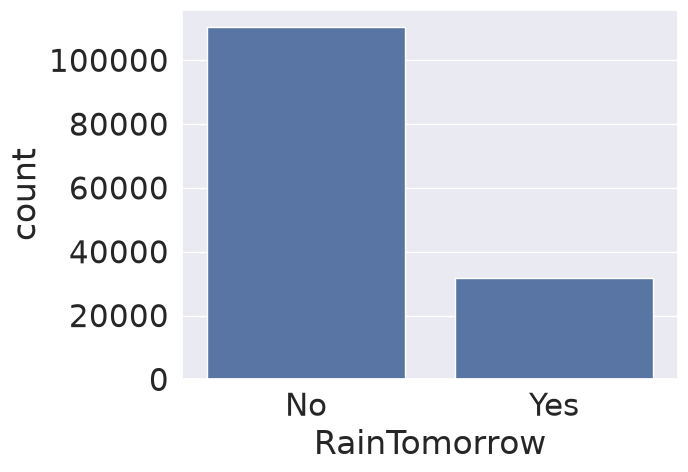

In [189]:
sns.countplot(x="RainTomorrow", data=df)

## 상관 분석(Correlation Analysis) 수행해보기

### 수치형 데이터 확인

In [265]:
# 수치형 데이터값만 따로 num_cols 선언

num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

In [ ]:

temp_df = df[num_cols]
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7


### 범주형 데이터를 수치형으로 변환
- RainToday, RainTomorrow 컬럼의 데이터를 수치형으로 변환
- 변환하여 수치형 데이터 프레임에 추가

In [ ]:
# temp_df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1}) #.astype(dtype='int')
# temp_df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1}) #.astype(dtype='int')

# 범주형 데이터를 수치형 데이터로 변환하는 나만의 함수 제작

def rain_number (rain) :
    if rain == 'No' :
        return 0
    else :
        return 1

temp_df['RainToday'] = df['RainToday'].apply(rain_number)
temp_df['RainTomorrow'] = df['RainTomorrow'].apply(rain_number)

In [193]:
temp_df.shape

(145460, 18)

In [194]:
temp_df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0,0
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0,0
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0,0
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0,0
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0


### 상관관계 계수 확인

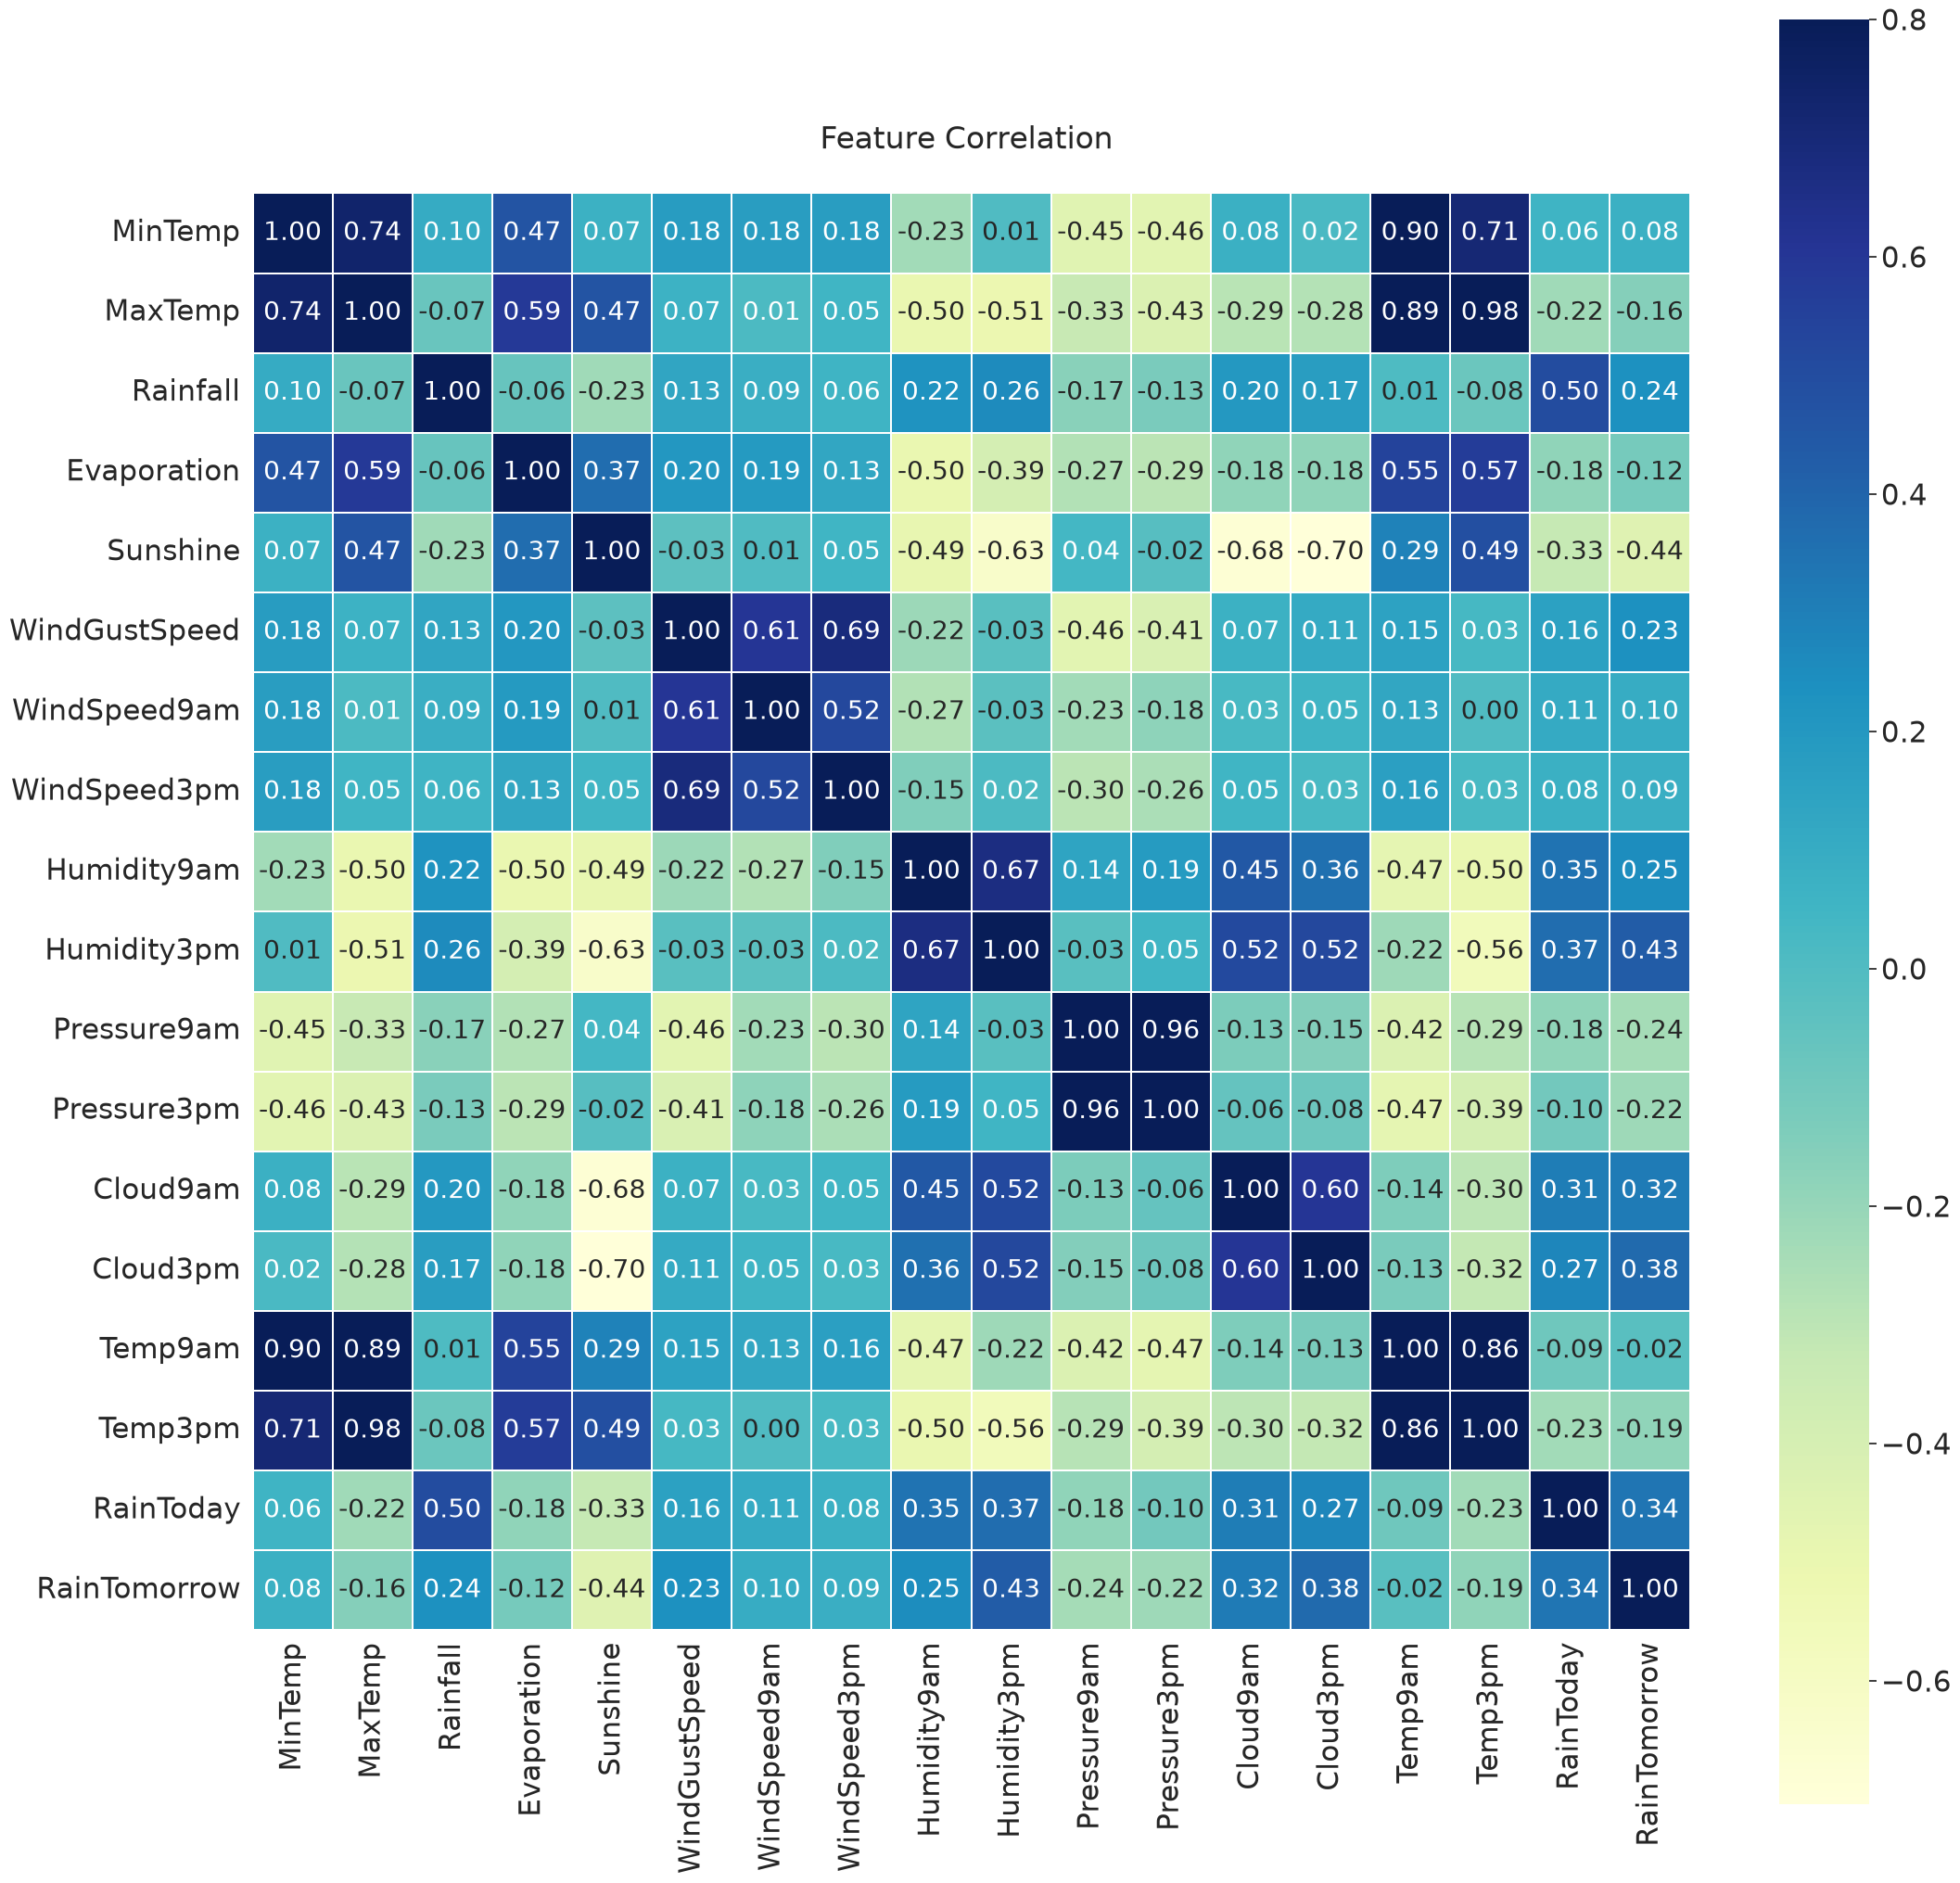

In [195]:
# target 과 연관관계가 높은 feature 의 이상치를 제거하기

corr = temp_df.corr()
plt.figure(figsize=(25, 25));
sns.set(font_scale=2.0); # plot의 글자크기 설정
sns.heatmap(corr,
            vmax=0.8,
            #vmin=-1,
            linewidths=0.01,
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 20},
            cmap='YlGnBu');
plt.title('Feature Correlation \n');

# 상관관계가 높은 feature columns : rainfall, humidity9am, humidity3pm, cloud9am, humidity3pm, RainToday

# 결측치 처리
## (null값) 확인하기

In [266]:
# null 의 개수 파악하기 (각 열에 얼마나 많은지 비율로 보기)

#df.isnull().mean().sort_values()

# isnull 은 boolean 값 -> T/F 에 따라 0/1 값의 평균을 통해 비율로 확인해보기 

df.isnull().sum()

MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
Sunshine          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 115, dtype: int64

## categorical column 확인하기

In [ ]:
cat_cols = df.select_dtypes(exclude=np.number).columns

cat_cols = cat_cols.drop('RainTomorrow') # 편하도록 rainTomorrow 는 미리 컬럼에서 제거하기

print(cat_cols)

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday'],
      dtype='str')


## numerical column 확인하기

In [198]:
num_cols = df.select_dtypes(include=np.number).columns
print(num_cols)

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')


# 결측치 개수 확인하기

In [199]:
df[cat_cols].isnull().mean().sort_values()

Date           0.000000
Location       0.000000
RainToday      0.022419
WindDir3pm     0.029066
WindGustDir    0.070989
WindDir9am     0.072639
dtype: float64

In [200]:
df[num_cols].isnull().mean().sort_values()

MaxTemp          0.008669
MinTemp          0.010209
WindSpeed9am     0.012148
Temp9am          0.012148
Humidity9am      0.018246
WindSpeed3pm     0.021050
Rainfall         0.022419
Temp3pm          0.024811
Humidity3pm      0.030984
WindGustSpeed    0.070555
Pressure3pm      0.103314
Pressure9am      0.103568
Cloud9am         0.384216
Cloud3pm         0.408071
Evaporation      0.431665
Sunshine         0.480098
dtype: float64

## 결측치 채우기
### 수치형 컬럼 결측처리
- numerical value를 가진 column은 중위값(meidan)으로 채우기

In [201]:
#df['Sunshine'].fillna(df['Sunshine'].median())
df['Sunshine'] = df['Sunshine'].fillna(df['Sunshine'].median())

In [ ]:
# 반복문을 통해 빠르게 중위값 채우기

for col in num_cols:
    if df[col].isnull().mean() > 0:
        col_median = df[col].median()
        df[col] = df[col].fillna(col_median)

### 범주형 컬럼 결측처리 
- null이 있는 범주형 컬럼 확인

In [203]:
for col in cat_cols:
    if df[col].isnull().mean() > 0:
        print(col, (df[col].isnull().mean()))

WindGustDir 0.0709885879279527
WindDir9am 0.07263852605527293
WindDir3pm 0.02906641000962464
RainToday 0.022418534304963565


In [204]:
# df['WindGustDir'].mode()
df['WindGustDir'].mode()[0]

'W'

In [ ]:
# 방법1
# categorical value를 가진 column은 최빈값(mode)으로 결측치 채우기
# RainTomorrow 는 target 이기 때문에 결측치 처리하지 않음.(일반적인 선택)
#df['WindGustDir'] = df['WindGustDir'].fillna(df['WindGustDir'].mode()[0])
#df['WindDir9am'] = df['WindDir9am'].fillna(df['WindDir9am'].mode()[0])
#df['WindDir3pm'] = df['WindDir3pm'].fillna(df['WindDir3pm'].mode()[0])
#df['RainToday'] = df['RainToday'].fillna(df['RainToday'].mode()[0])

# 범주형 컬럼의 결측치를 처리하는 나만의 반복문 생성하기 
# 어차피 RainTomorrow 제외했으니 !!

for col in cat_cols :
    if df[col].isnull().mean() > 0 : # 결측치가 존재한다면
        mode1 = df[col].mode()[0]
        df[col] = df[col].fillna(mode1)

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [206]:
df['RainTomorrow'].mode()[0]


'No'

In [85]:
# cat_cols= list(cat_cols)
# cat_cols

In [86]:
# cat_cols.remove('RainTomorrow')
# cat_cols

In [87]:
# 방법2
# for col in cat_cols:
#     if df[col].isnull().mean() > 0:
#         df[col] = df[col].fillna(df[col].mode()[0])

In [207]:
df.info() # Target 인 RainTomorrow 제거하고 나머지 모두 결측치 처리 완료

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  str    
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  str    
 10  WindDir3pm     145460 non-null  str    
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-null  float64


In [208]:
df.isnull().sum()

Date                0
Location            0
MinTemp             0
MaxTemp             0
Rainfall            0
Evaporation         0
Sunshine            0
WindGustDir         0
WindGustSpeed       0
WindDir9am          0
WindDir3pm          0
WindSpeed9am        0
WindSpeed3pm        0
Humidity9am         0
Humidity3pm         0
Pressure9am         0
Pressure3pm         0
Cloud9am            0
Cloud3pm            0
Temp9am             0
Temp3pm             0
RainToday           0
RainTomorrow     3267
dtype: int64

## 필요 없는 컬럼 삭제 

In [209]:
df = df.drop(['Date'], axis=1)

In [210]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [211]:
df.isnull().mean().sort_values()

Location         0.00000
MinTemp          0.00000
MaxTemp          0.00000
Rainfall         0.00000
Evaporation      0.00000
Sunshine         0.00000
WindGustDir      0.00000
WindGustSpeed    0.00000
WindDir9am       0.00000
WindDir3pm       0.00000
WindSpeed9am     0.00000
WindSpeed3pm     0.00000
Humidity9am      0.00000
Humidity3pm      0.00000
Pressure9am      0.00000
Pressure3pm      0.00000
Cloud9am         0.00000
Cloud3pm         0.00000
Temp9am          0.00000
Temp3pm          0.00000
RainToday        0.00000
RainTomorrow     0.02246
dtype: float64

## target의 null 값처리
- RainTomorrow는 target이기 때문에 nan은 drop으로 처리
- RainTomorrow 예측 값이므로 null 값 삭제함

In [212]:
df.shape

(145460, 22)

In [213]:
df.shape

(145460, 22)

In [214]:
df.isnull().sum()

Location            0
MinTemp             0
MaxTemp             0
Rainfall            0
Evaporation         0
Sunshine            0
WindGustDir         0
WindGustSpeed       0
WindDir9am          0
WindDir3pm          0
WindSpeed9am        0
WindSpeed3pm        0
Humidity9am         0
Humidity3pm         0
Pressure9am         0
Pressure3pm         0
Cloud9am            0
Cloud3pm            0
Temp9am             0
Temp3pm             0
RainToday           0
RainTomorrow     3267
dtype: int64

In [215]:
#df = df.dropna(subset=['RainTomorrow']) # Raintomorrow 열의 값이 NaN 인 행을 모두 삭제하기
df = df.dropna() # 현재는 결측치를 제거하였기에 사실상 subset 지정하지 않아도 의미가 같긴 함
df.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       142193 non-null  str    
 1   MinTemp        142193 non-null  float64
 2   MaxTemp        142193 non-null  float64
 3   Rainfall       142193 non-null  float64
 4   Evaporation    142193 non-null  float64
 5   Sunshine       142193 non-null  float64
 6   WindGustDir    142193 non-null  str    
 7   WindGustSpeed  142193 non-null  float64
 8   WindDir9am     142193 non-null  str    
 9   WindDir3pm     142193 non-null  str    
 10  WindSpeed9am   142193 non-null  float64
 11  WindSpeed3pm   142193 non-null  float64
 12  Humidity9am    142193 non-null  float64
 13  Humidity3pm    142193 non-null  float64
 14  Pressure9am    142193 non-null  float64
 15  Pressure3pm    142193 non-null  float64
 16  Cloud9am       142193 non-null  float64
 17  Cloud3pm       142193 non-null  float64
 18  

In [216]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,4.8,8.4,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,4.8,8.4,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,4.8,8.4,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,4.8,8.4,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,4.8,8.4,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# Yes/No 값에 대한 변환

In [217]:
#df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
#df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# 함수로 값 인코딩하기 

def strtonum (yesorno) :
    if yesorno == 'No' :
        return 0
    else : 
        return 1

df['RainToday'] = df['RainToday'].apply(strtonum)
df['RainTomorrow'] = df['RainTomorrow'].apply(strtonum)

print(df['RainToday'].dtype, df['RainTomorrow'].dtype)

int64 int64


## categorical value에 one-hot encoding 적용하기

In [218]:
cat_cols

Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday'],
      dtype='str')

In [219]:
# Pandas 의 one-hot encoding 적용하는 방법

df = pd.get_dummies(df, columns = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'])

In [220]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000,142193.000000
mean,12.185565,23.225365,2.326738,5.183213,7.994543,39.920123,13.992489,18.644279,68.858235,51.495742,1017.648460,1015.252481,4.649568,4.702658,16.985681,21.675977,0.221213,0.224181
std,6.388936,7.109617,8.426426,3.185401,2.762195,13.140632,8.851614,8.721688,18.932512,20.532227,6.746267,6.681810,2.294357,2.118753,6.472206,6.871243,0.415065,0.417043
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000,0.000000
25%,7.600000,17.900000,0.000000,4.000000,8.200000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.000000,3.000000,4.000000,12.300000,16.700000,0.000000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,0.000000
75%,16.800000,28.200000,0.600000,5.400000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.300000,0.000000,0.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,1.000000,1.000000


In [221]:
df['WindDir3pm_NW']

0         False
1         False
2         False
3         False
4          True
          ...  
145454    False
145455    False
145456    False
145457    False
145458    False
Name: WindDir3pm_NW, Length: 142193, dtype: bool

In [222]:
df.shape

(142193, 115)

# ML을 위한 학습, 테스트 데이터 준비

In [223]:
# [문제] 특징 변수와 타겟 변수 분할 하기
# X = df.loc[:, :'RainToday']
# y = df['RainTomorrow']

# One Hot Encoding 시 위치 이슈 ! 따라서 위치로 하지 말고 직접 선언

X = df.drop('RainTomorrow', axis = 1)
y = df['RainTomorrow']

In [224]:
X.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


In [225]:
y[:5]

0    0
1    0
2    0
3    0
4    0
Name: RainTomorrow, dtype: int64

In [226]:
y.value_counts()

RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

In [227]:
from sklearn.model_selection import train_test_split

In [228]:
# [문제]  학습, 테스트 데이터 분할 하기
# 학습 : 테스트 = 7 : 3 
# 불균형 데이터 이므로 stratify = y 로 설정
# 재현을 위해 seed 값은 2026 설정


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 2026, stratify = y)

In [229]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((99535, 114), (42658, 114), (99535,), (42658,))

# ML 모델 학습

## 결정 트리(Decision Tree)로 내일 비가 올지 안올지 예측해보기

In [238]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
# [문제] 결정 트리 모델 학습 및 예측 수행
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train,y_train)


y_pred1 = dt_clf.predict(X_test)

In [239]:
y_pred1

array([0, 0, 0, ..., 0, 0, 0], shape=(42658,))

In [240]:
# [문제] 결정 트리 정확도 출력
score = accuracy_score(y_test, y_pred1)
print('결정 트리(Decision Tree) Accuracy :',score)

결정 트리(Decision Tree) Accuracy : 0.7881991654554832


### [문제] 정확도, 정밀도, 재현율, f1-스코아를 값을 확인해 보세요.

In [241]:
from sklearn.metrics import classification_report
# [문제] classification_report() 결과 출력

print("[정확도, 정밀도, 재현율, f1-score 값 정리] \n")
print(classification_report(y_test, y_pred1))

[정확도, 정밀도, 재현율, f1-score 값 정리] 

              precision    recall  f1-score   support

           0       0.87      0.86      0.86     33095
           1       0.53      0.54      0.53      9563

    accuracy                           0.79     42658
   macro avg       0.70      0.70      0.70     42658
weighted avg       0.79      0.79      0.79     42658



In [247]:
# [문제] roc_auc_score 출력, 소숫점 첫째자리까지만 출력
from sklearn.metrics import roc_auc_score
roc_result1 = roc_auc_score(y_test, y_pred1)
print(f"{roc_result1: .1f}")

 0.7


## 랜덤 포레스트(Random Forest)로  
- 참고 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- DT default = 100개를 만들어서 학습을 시킴

In [243]:
from sklearn.ensemble import RandomForestClassifier
# [문제] RandomForestClassifier 분류 모델 학습 및 예측 수행

rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

y_pred2 = rf_clf.predict(X_test)

In [244]:
y_pred2

array([0, 0, 1, ..., 0, 0, 0], shape=(42658,))

In [245]:
# 정확도 평가
score = accuracy_score(y_test, y_pred2)
print('랜덤 포레스트(Random Forest) Accuracy :', score)

랜덤 포레스트(Random Forest) Accuracy : 0.8547751887102067


In [246]:
from sklearn.metrics import classification_report
# classification_report() 결과 출력

print("[정확도, 정밀도, 재현율, f1-score 값 정리] \n")
print(classification_report(y_test, y_pred2))

[정확도, 정밀도, 재현율, f1-score 값 정리] 

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     33095
           1       0.78      0.49      0.60      9563

    accuracy                           0.85     42658
   macro avg       0.82      0.73      0.76     42658
weighted avg       0.85      0.85      0.84     42658



In [248]:
# [문제] roc_auc_score 출력, 소숫점 둘째자리까지만 출력
from sklearn.metrics import roc_auc_score

roc_result2 = roc_auc_score(y_test, y_pred2)
print(f"{roc_result2 :.2f}")

0.73


# XGBoost 분류기

In [249]:
from xgboost import XGBClassifier
# [문제] xgboost 학습 수행 및 예측
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred3 = xgb.predict(X_test)

In [251]:
print(accuracy_score(y_test, y_pred3))

0.857939894040977


In [250]:
from sklearn.metrics import classification_report
# [문제] classification_report() 결과 출력

print("[정확도, 정밀도, 재현율, f1-score 값 정리] \n")
print(classification_report(y_test, y_pred3))

[정확도, 정밀도, 재현율, f1-score 값 정리] 

              precision    recall  f1-score   support

           0       0.88      0.95      0.91     33095
           1       0.75      0.55      0.64      9563

    accuracy                           0.86     42658
   macro avg       0.81      0.75      0.77     42658
weighted avg       0.85      0.86      0.85     42658



In [254]:
# [문제] roc_auc_score 출력, 소숫점 둘째자리까지만 출력

# 소숫점 셋째자리까지 출력해보기 !!

from sklearn.metrics import roc_auc_score

roc_result3 = roc_auc_score(y_test, y_pred3)
print(f"{roc_result3 :.3f}")

0.750


In [264]:
# 모델별 accuracy / precision 비교
# - weighted avg precision뿐 아니라, 실제 관심 대상인 'RainTomorrow=1(비 옴)' 클래스의 precision/recall/f1도 함께 비교

from sklearn.metrics import classification_report, accuracy_score

model_names = ['Decision Tree', 'Random Forest', 'XGBoost']
y_preds = [y_pred1, y_pred2, y_pred3]

rows = []
for name, y_pred in zip(model_names, y_preds):
    report = classification_report(y_test, y_pred, output_dict=True)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision(weighted avg)': report['weighted avg']['precision'],
        'precision(RainTomorrow=1)': report['1']['precision'],
        'recall(RainTomorrow=1)': report['1']['recall'],
        'f1-score(RainTomorrow=1)': report['1']['f1-score'],
    })

result_df = pd.DataFrame(rows).set_index('model')
result_df

,accuracy,precision(weighted avg),precision(RainTomorrow=1),recall(RainTomorrow=1),f1-score(RainTomorrow=1)
model,,,,,
Decision Tree,0.788199,0.790180,0.526906,0.540625,0.533677
Random Forest,0.854775,0.847348,0.776610,0.494406,0.604179
XGBoost,0.857940,0.850239,0.746378,0.554847,0.636516


In [ ]:
# 한글 폰트 설정

import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


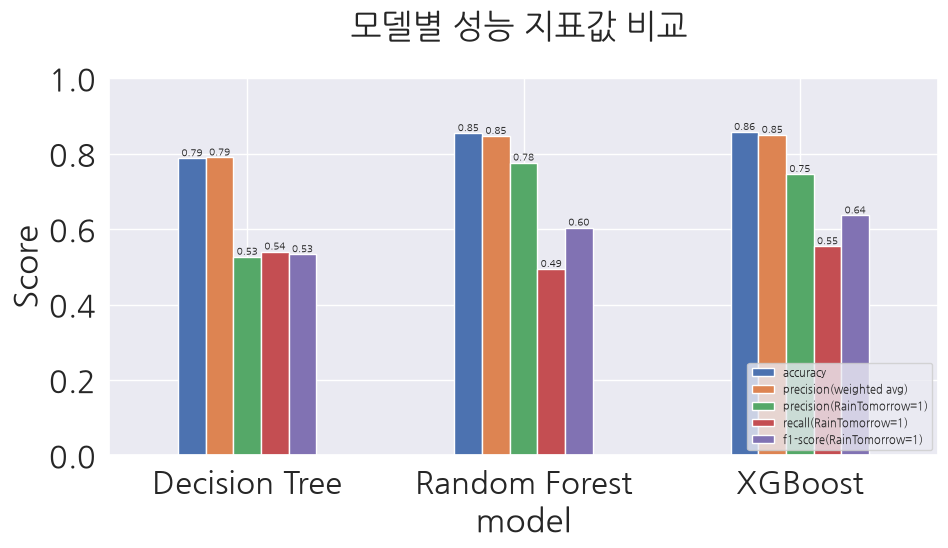

In [ ]:
# 지표별 비교 막대그래프

fig, ax = plt.subplots(figsize=(10, 6))
result_df.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('모델별 성능 지표값 비교 \n')
ax.legend(loc='lower right', fontsize=8)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 최종적으로 가장 베스트한 모델은 ?

> 해당 모델에서 **중요한 지표**는 무엇일까?

- 현재의 날씨 예측은 "비 오는 날을 놓치지 않고 얼마나 잘 예측할 것인가?" 이다. 정밀도(precision) 의 경우에는, 내가 비가 온다고 예측한 답이 얼마나 정밀한지, 오보율을 볼 수 있는 지표가 될 수 있지만 현재 더 필요한 것은 비가 오는 날을 잘 맞춘다는 지표인 재현율, recall 값이 중요하다고 생각한다.
    - 결국 이 경우에는 모델의 recall, 재현율값이 중요하다.
- 실제 1 (RainTomorrow = Yes) 의 recall 값을 보았을 때,
    - Decision Tree : 0.54
    - Random Forest : 0.49
    - XGBoost Classifier : 0.55 -> **선정**

> 결론 : XGBoost Classifier 모델이 '내일 비가 오는지 맞추는' 모델에 대해서는 적합한 분류기라고 판단할 수 있다.